In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from figures_setup import *
from utils import set_color_code
import palantir

# SG treatment of liver metastasis (time course)

## Getting data from arrayExpress: E-MTAB-16849 (dataset 0h-48h)

In [3]:
# Download data from arrayExpress and reassemble anndata object 
from utils_arrayExpress import list_accession_files

accession = "E-MTAB-16849"
download_dir = '../data_arrayExpress'

# List files for the given accession
file_list = list_accession_files(accession, download_dir)
# Show only files ending with palantir.h5ad
palantir_files = file_list[file_list['path'].str.endswith('palantir.h5ad')]
palantir_files

,path,size,type,md5
4,HD4246_SG_0h-48h_palantir.h5ad,4470781922,file,None
6,HD4246_SG_48-120h_palantir.h5ad,5447792258,file,None


In [4]:
# Read palantir dataset
file = os.path.join(download_dir, accession, 'HD4246_SG_0h-48h_palantir.h5ad')
adata = sc.read_h5ad(file)
adata

AnnData object with n_obs × n_vars = 11337 × 27594
    obs: 'sample_id', 'line', 'treatment', 'timepoint', 'replicate', 'library', 'leiden', 'batch', 'palantir_pseudotime', 'palantir_entropy'
    var: 'dispersions', 'dispersions_norm', 'gene_trends_clusters'
    uns: 'DM_EigenValues', 'leiden_colors', 'neighbors', 'palantir_start_state', 'palantir_terminal_states', 'palantir_waypoints', 'sample_id_colors', 'timepoint_colors', 'treatment_colors'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_pca', 'X_umap', 'branch_masks', 'palantir_fate_probabilities'
    varm: 'PCs', 'gene_trends_Term_DM1_max', 'gene_trends_Term_DM2_min'
    layers: 'MAGIC_imputed_data'
    obsp: 'DM_Kernel', 'DM_Similarity', 'connectivities', 'distances'

In [5]:
# Pick branch color from color code
from utils_SG_timecourse import color_code
branches = ['Term_DM2_min', 'Term_DM1_max']
branch_color = {
    'Term_DM2_min': '#672892',
    'Term_DM1_max': '#854f9c',
}
# Mapping of interpretable branch names
branch_title = {
    "Term_DM2_min": "Main trajectory",
    "Term_DM1_max": "Side trajectory",
}

### Plotting palantir results

[2026-05-11 12:29:19,347] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (3,118) and rank = 1.0.
[2026-05-11 12:29:19,348] [INFO    ] Using covariance function Matern52(ls=0.8957839012145996).
[2026-05-11 12:29:19,362] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-05-11 12:29:21,301] [INFO    ] Sigma interpreted as element-wise standard deviation.
[2026-05-11 12:29:21,782] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (3,148) and rank = 1.0.
[2026-05-11 12:29:21,783] [INFO    ] Using covariance function Matern52(ls=0.8957839012145996).
[2026-05-11 12:29:21,795] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-05-11 12:29:22,686] [INFO    ] Sigma interpreted as element-wise standard deviation.


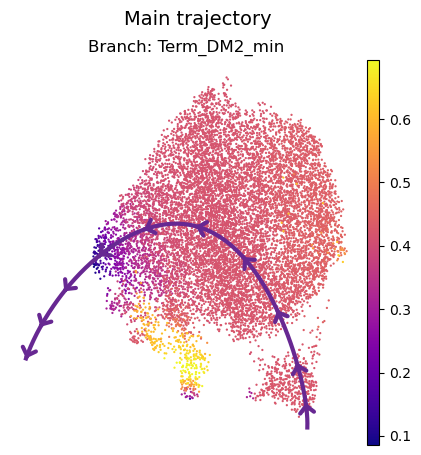

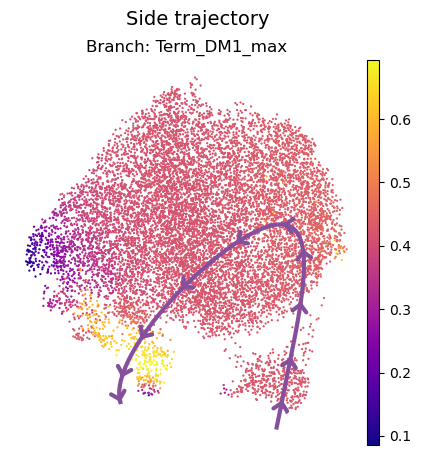

In [6]:
# Plot branches on UMAP colored by entropy
entropy_cmap = 'plasma'

for branch in branches:
    color = 'palantir_entropy'
    palantir.plot.plot_trajectory(
        adata, # your anndata
        branch, # the branch to plot
        cell_color="palantir_entropy", # the ad.obs colum to color the cells by
        n_arrows=10, # the number of arrow heads along the path
        color=branch_color[branch], # the color of the path and arrow heads
        scanpy_kwargs=dict(cmap=entropy_cmap), # arguments passed to scanpy.pl.embedding
        arrowprops=dict(arrowstyle="->,head_length=.5,head_width=.5", lw=3), # appearance of the arrow heads
        lw=3, # thickness of the path
        pseudotime_interval=(0, .9), # interval of the pseudotime to cover with the path
    )
    fig = plt.gcf()
    fig.suptitle(branch_title[branch], fontsize=14)
    fig.show()

In [7]:
# Compute gene trends
gene_trends = palantir.presults.compute_gene_trends(
    adata,
    expression_key="MAGIC_imputed_data",
)

Term_DM1_max
[2026-05-11 12:29:23,723] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (3,148) and rank = 1.0.
[2026-05-11 12:29:23,724] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-05-11 12:29:24,695] [INFO    ] Sigma interpreted as element-wise standard deviation.
Term_DM2_min
[2026-05-11 12:29:28,914] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (3,118) and rank = 1.0.
[2026-05-11 12:29:28,915] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-05-11 12:29:29,394] [INFO    ] Sigma interpreted as element-wise standard deviation.


In [8]:
# Extract gene expression along pseudotime
genes = ["TACSTD2", "LGR5"]

df_expr = pd.concat(
    {
        (gene, br): (
            adata.varm[f"gene_trends_{br}"]
            .loc[gene]
            .astype(float)
            .reset_index(drop=True)
        )
        for gene in genes
        for br in branches
    },
    axis=1
)

df_expr.index.name = "pseudotime_bin"

df_expr.head(2)

TACSTD2                      LGR5             
               Term_DM2_min Term_DM1_max Term_DM2_min Term_DM1_max
pseudotime_bin                                                    
0                  2.656494     2.664230     0.097860     0.071987
1                  2.654413     2.660632     0.098086     0.072855

In [9]:
import matplotlib.pyplot as plt

def plot_gene_expression_from_df(df_expr, 
                                 branch_name,
                                 color_trop2='green', 
                                 color_lgr5='red',
                                 linewidth=4,
                                 scale_min_max = False,
                                 title = None,
                                 figsize=(8, 6)):
    # Extract expression data for both genes from the df_expr dictionary
    tacstd2_expr = df_expr[('TACSTD2', branch_name)]  # Directly use the ndarray
    lgr5_expr = df_expr[('LGR5', branch_name)]  # Directly use the ndarray

    # Scale expression per gene if indicated
    if scale_min_max:
        tac_min, tac_max = np.nanmin(tacstd2_expr), np.nanmax(tacstd2_expr)
        lgr5_min, lgr5_max = np.nanmin(lgr5_expr), np.nanmax(lgr5_expr)

        # avoid division by zero if a gene is constant
        if tac_max > tac_min:
            tacstd2_expr = (tacstd2_expr - tac_min) / (tac_max - tac_min)
        else:
            tacstd2_expr = np.zeros_like(tacstd2_expr, dtype=float)

        if lgr5_max > lgr5_min:
            lgr5_expr = (lgr5_expr - lgr5_min) / (lgr5_max - lgr5_min)
        else:
            lgr5_expr = np.zeros_like(lgr5_expr, dtype=float)
        

    # Create an array for pseudotime (assuming row indices represent pseudotime points)
    pseudotime = range(len(tacstd2_expr))

    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)

    # Plot the expression for TACSTD2 and LGR5
    ax.plot(pseudotime, tacstd2_expr, label='TACSTD2', color=color_trop2, linewidth=linewidth)
    ax.plot(pseudotime, lgr5_expr, label='LGR5', color=color_lgr5, linewidth=linewidth)

    # Add labels and title
    title = "" if title is None else title
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Pseudotime", fontsize=14)
    ax.set_ylabel("Scaled expression", fontsize=14)

    # Add a legend
    ax.legend(title="", frameon=False)

    # Show the plot
    plt.tight_layout()
    plt.show()

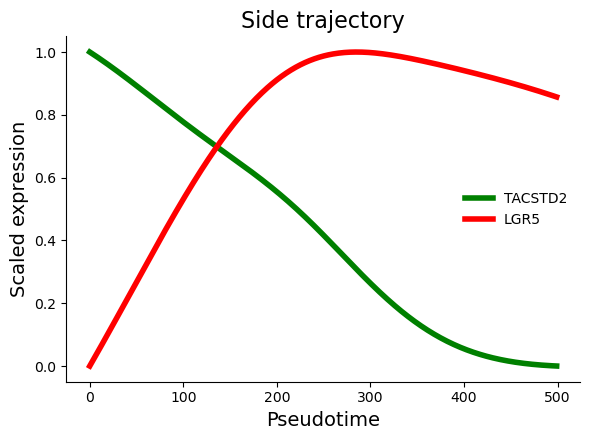

In [10]:
# Get scaled gene expression along pseudotime for main trajectory (Term_DM2_min)
plot_gene_expression_from_df(
    df_expr, 
    branch_name='Term_DM1_max', 
    scale_min_max=True,
    title = "Side trajectory",
    figsize=(6, 4.5),
)

## Getting data from arrayExpress: E-MTAB-16849 (dataset 48h-120h)

In [21]:
# Download data from arrayExpress and reassemble anndata object 
from utils_arrayExpress import list_accession_files

accession = "E-MTAB-16849"
download_dir = '../data_arrayExpress'

# List files for the given accession
file_list = list_accession_files(accession, download_dir)
# Show only files ending with palantir.h5ad
palantir_files = file_list[file_list['path'].str.endswith('palantir.h5ad')]
palantir_files

,path,size,type,md5
4,HD4246_SG_0h-48h_palantir.h5ad,4470781922,file,None
6,HD4246_SG_48-120h_palantir.h5ad,5447792258,file,None


In [12]:
# Read palantir dataset
file = os.path.join(download_dir, accession, 'HD4246_SG_48-120h_palantir.h5ad')
adata = sc.read_h5ad(file)
adata

AnnData object with n_obs × n_vars = 13929 × 27594
    obs: 'sample_id', 'line', 'treatment', 'timepoint', 'replicate', 'library', 'leiden', 'batch', 'palantir_pseudotime', 'palantir_entropy'
    var: 'dispersions', 'dispersions_norm', 'gene_trends_clusters'
    uns: 'DM_EigenValues', 'leiden_colors', 'neighbors', 'palantir_start_state', 'palantir_terminal_states', 'palantir_waypoints', 'sample_id_colors', 'timepoint_colors', 'treatment_colors'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_pca', 'X_umap', 'branch_masks', 'palantir_fate_probabilities'
    varm: 'PCs', 'gene_trends_Term_DM3_min', 'gene_trends_Term_umap2_min'
    layers: 'MAGIC_imputed_data'
    obsp: 'DM_Kernel', 'DM_Similarity', 'connectivities', 'distances'

In [13]:
adata.uns['palantir_terminal_states']

{'cell_ids': array(['ATTGGCGCAGGATTAC-1-12', 'TATCGTAGTGAGGACT-1-2'], dtype=object),
 'state_names': array(['Term_umap2_min', 'Term_DM3_min'], dtype=object)}

In [14]:
# Pick branch color from color code
branches = ['Term_umap2_min', 'Term_DM3_min']
branch_color = {
    'Term_umap2_min':  '#737379',
    'Term_DM3_min': '#9d9da1',
}
# Mapping of interpretable branch names
branch_title = {
    "Term_umap2_min": "Main trajectory",
    "Term_DM3_min": "Side trajectory",
}

### Plotting palantir results

[2026-05-11 12:29:41,176] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (1,079) and rank = 1.0.
[2026-05-11 12:29:41,176] [INFO    ] Using covariance function Matern52(ls=0.8594485282897949).
[2026-05-11 12:29:41,190] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).


[2026-05-11 12:29:41,988] [INFO    ] Sigma interpreted as element-wise standard deviation.
[2026-05-11 12:29:42,090] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (1,452) and rank = 1.0.
[2026-05-11 12:29:42,091] [INFO    ] Using covariance function Matern52(ls=0.8594485282897949).
[2026-05-11 12:29:42,104] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-05-11 12:29:43,084] [INFO    ] Sigma interpreted as element-wise standard deviation.


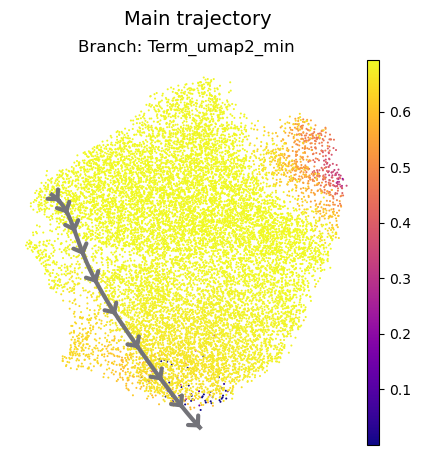

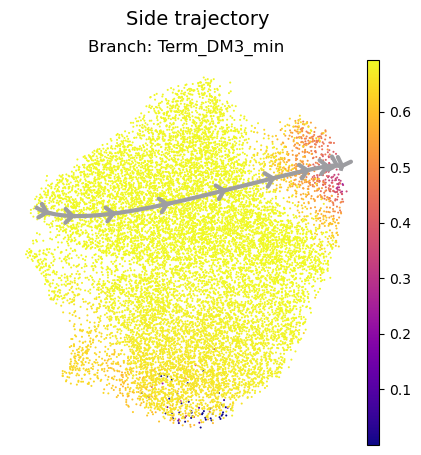

In [15]:
# Plot branches on UMAP colored by entropy
entropy_cmap = 'plasma'

for branch in branches:
    color = 'palantir_entropy'
    palantir.plot.plot_trajectory(
        adata,
        branch,
        cell_color="palantir_entropy",
        n_arrows=10,
        color=branch_color[branch],
        scanpy_kwargs=dict(cmap=entropy_cmap), 
        arrowprops=dict(arrowstyle="->,head_length=.5,head_width=.5", lw=3),
        lw=3, 
        pseudotime_interval=(0, .9), 
    )
    fig = plt.gcf()
    fig.suptitle(branch_title[branch], fontsize=14)
    fig.show()

In [16]:
# Compute gene trends
gene_trends = palantir.presults.compute_gene_trends(
    adata,
    expression_key="MAGIC_imputed_data",
)

Term_umap2_min
[2026-05-11 12:29:43,964] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (1,079) and rank = 1.0.
[2026-05-11 12:29:43,965] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-05-11 12:29:44,398] [INFO    ] Sigma interpreted as element-wise standard deviation.
Term_DM3_min
[2026-05-11 12:29:47,231] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (1,452) and rank = 1.0.
[2026-05-11 12:29:47,231] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-05-11 12:29:47,690] [INFO    ] Sigma interpreted as element-wise standard deviation.


In [17]:
# Extract gene expression along pseudotime
genes = ["TACSTD2", "LGR5"]

df_expr = pd.concat(
    {
        (gene, br): (
            adata.varm[f"gene_trends_{br}"]
            .loc[gene]
            .astype(float)
            .reset_index(drop=True)
        )
        for gene in genes
        for br in branches
    },
    axis=1
)

df_expr.index.name = "pseudotime_bin"
df_expr.head(2)

TACSTD2                        LGR5             
               Term_umap2_min Term_DM3_min Term_umap2_min Term_DM3_min
pseudotime_bin                                                        
0                    0.737753     0.508265       0.425576     0.438346
1                    0.739296     0.512501       0.424621     0.437236

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_gene_expression_from_df(
    df_expr,
    branches='Term_DM3_min',
    gene_1='TACSTD2',
    gene_2='LGR5',
    branch_linestyles=None,
    branch_to_cond=None,
    color_gene_1='green',
    color_gene_2='red',
    linewidth=4,
    scale_min_max=False,
    title=None,
    figsize=(8, 6),
):
    """
    Plot expression trends for two genes across one or multiple trajectories.

    Encoding:
    - color = gene
    - linestyle = branch
    """

    def _minmax_scale(x):
        x = np.asarray(x, dtype=float)
        xmin, xmax = np.nanmin(x), np.nanmax(x)
        if xmax > xmin:
            return (x - xmin) / (xmax - xmin)
        return np.zeros_like(x, dtype=float)

    if isinstance(branches, str):
        branches = [branches]

    if branch_to_cond is None:
        branch_to_cond = {br: br for br in branches}

    if branch_linestyles is None:
        default_styles = ['-', '--', ':', '-.']
        branch_linestyles = {
            br: default_styles[i % len(default_styles)]
            for i, br in enumerate(branches)
        }

    gene_colors = {
        gene_1: color_gene_1,
        gene_2: color_gene_2
    }

    fig, ax = plt.subplots(figsize=figsize)

    for br in branches:
        if (gene_1, br) not in df_expr:
            print(f"Warning: ({gene_1}, {br}) not found in df_expr. Skipping.")
            continue
        if (gene_2, br) not in df_expr:
            print(f"Warning: ({gene_2}, {br}) not found in df_expr. Skipping.")
            continue

        expr_1 = np.asarray(df_expr[(gene_1, br)], dtype=float)
        expr_2 = np.asarray(df_expr[(gene_2, br)], dtype=float)

        if scale_min_max:
            expr_1 = _minmax_scale(expr_1)
            expr_2 = _minmax_scale(expr_2)

        pseudotime_1 = np.arange(len(expr_1))
        pseudotime_2 = np.arange(len(expr_2))

        linestyle = branch_linestyles.get(br, '-')

        ax.plot(
            pseudotime_1, expr_1,
            color=gene_colors[gene_1],
            linewidth=linewidth,
            linestyle=linestyle
        )
        ax.plot(
            pseudotime_2, expr_2,
            color=gene_colors[gene_2],
            linewidth=linewidth,
            linestyle=linestyle
        )

    if title is None:
        if len(branches) == 1:
            title = f"Gene Expression Trends for {gene_1} and {gene_2}"
        else:
            title = f"Gene Expression Trends across Trajectories: {gene_1} and {gene_2}"

    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Pseudotime", fontsize=14)
    ax.set_ylabel("Expression" if not scale_min_max else "Scaled expression", fontsize=14)

    if len(branches) == 1:
        gene_handles = [
            Line2D([0], [0], color=gene_colors[gene_1], lw=linewidth, linestyle='-', label=gene_1),
            Line2D([0], [0], color=gene_colors[gene_2], lw=linewidth, linestyle='-', label=gene_2)
        ]
        ax.legend(handles=gene_handles, title="Gene", frameon=False)
    else:
        gene_handles = [
            Line2D([0], [0], color=gene_colors[gene_1], lw=linewidth, linestyle='-', label=gene_1),
            Line2D([0], [0], color=gene_colors[gene_2], lw=linewidth, linestyle='-', label=gene_2)
        ]
        branch_handles = [
            Line2D([0], [0], color='black', lw=linewidth, linestyle=branch_linestyles[br], label=branch_to_cond.get(br, br))
            for br in branches
        ]

        leg1 = ax.legend(
            handles=gene_handles,
            title="Gene",
            frameon=False,
            loc='upper left',
            bbox_to_anchor=(1.02, 0.75),
            borderaxespad=0
        )
        ax.add_artist(leg1)

        ax.legend(
            handles=branch_handles,
            title="Trajectory",
            frameon=False,
            loc='upper left',
            bbox_to_anchor=(1.02, 0.3),
            borderaxespad=0
        )

    plt.tight_layout()
    plt.show()

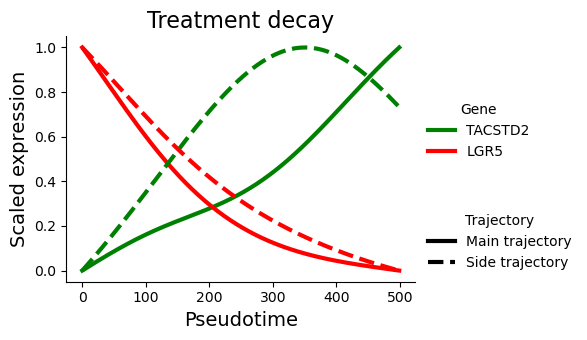

In [19]:
# Define the branches and their colors
branch_linestyles = {
    'Term_DM3_min': '--',
    'Term_umap2_min': '-'
}

# Define the branches and their colors
plot_gene_expression_from_df(
    df_expr,
    branches=branches,
    gene_1='TACSTD2',
    gene_2='LGR5',
    color_gene_1='green',
    color_gene_2='red',
    branch_linestyles=branch_linestyles,
    linewidth=3,
    branch_to_cond=branch_title,
    scale_min_max=True,
    title = "Treatment decay",
    figsize=(6, 3.5)
)

# Session info

The analysis above has been performed using a micromamba environment with the following package versions:

In [20]:
session_info.show()